In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import os
from scripts.data_preprocess import bib_to_csv, json_to_csv
import matplotlib.pyplot as plt


#### Getting the data

In [2]:
valid_dois_df = pd.read_csv("data/processed/fetched_dois.csv")
valid_dois = set(valid_dois_df["doi"].dropna().astype(str).str.lower().str.strip())

In [3]:
springer = json_to_csv("data/raw/API_search/springer_api_metadata.JSON", "data/processed/springer_query_2026-03-02.csv", valid_dois)

In [4]:
acm_paths = ["data/raw/manual_search/ACM/acm_query_abstract_2026-03-02.bib", "data/raw/manual_search/ACM/acm_query_title_2026-03-02.bib"]
acm_raw = bib_to_csv(acm_paths, "data/processed/acm_query_2026-03-02.csv")

sd_raw = bib_to_csv("data/raw/manual_search/ScienceDirect/sd_query_2026-03-02.bib", "data/processed/sd_query_2026-03-02.csv")

In [5]:
def load_with_source(folder_path, source_name):
    folder = Path(folder_path)
    dfs = []
    for file in folder.glob("*.csv"):
        df = pd.read_csv(file)
        df["source"] = source_name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [6]:
springer_orig1 = pd.read_csv("data/raw/manual_search/Springer/springer_query_-2024_2026-03-02.csv")
springer_orig2 = pd.read_csv("data/raw/manual_search/Springer/springer_query_2025-2026_2026-03-02.csv")

springer_original = pd.concat([springer_orig1, springer_orig2], ignore_index=True)

orig_dois = (
    springer_original["Item DOI"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
)

orig_dois = set(orig_dois)

springer_meta = pd.read_csv("data/processed/springer_query_2026-03-02.csv")

meta_dois = (
    springer_meta["doi"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
)

meta_dois = set(meta_dois)
missing = orig_dois - meta_dois
extra = meta_dois - orig_dois

print("Original DOIs:", len(orig_dois))
print("Metadata DOIs:", len(meta_dois))
print("Missing DOIs:", len(missing))
print("Extra DOIs:", len(extra))

springer_meta = springer_meta[
    springer_meta["doi"].str.lower().isin(orig_dois)
]

print(len(springer_meta))
print(springer_meta["doi"].nunique())

Original DOIs: 1499
Metadata DOIs: 1499
Missing DOIs: 0
Extra DOIs: 0
1624
1499


In [7]:
# getting the data
ieee = load_with_source("data/raw/manual_search/IEEE", "IEEE")

sd = pd.read_csv("data/processed/sd_query_2026-03-02.csv")
sd["source"] = "ScienceDirect"

acm = pd.read_csv("data/processed/acm_query_2026-03-02.csv")
acm["source"] = "ACM"

springer = pd.read_csv("data/processed/springer_query_2026-03-02.csv")
springer["source"] = "Springer"


In [8]:
print(springer["doi"].nunique())
print(sd["doi"].nunique())
print(acm["doi"].nunique())
print(ieee["DOI"].nunique())

1499
49
71
314


In [9]:
# create table to keep track of counts
count_columns = ["data", "ACM", "IEEE", "Springer", "ScienceDirect"]

count_db = pd.DataFrame(columns = count_columns)
count_db.loc[0] = ["raw", len(acm), len(ieee), len(springer), len(sd)]
count_db

,data,ACM,IEEE,Springer,ScienceDirect
0,raw,78,337,1624,49


In [10]:
# Remove duplicates based on DOI for each dataset
acm.drop_duplicates(subset="doi", inplace=True)
ieee.drop_duplicates(subset="DOI", inplace=True)
springer.drop_duplicates(subset="doi", inplace=True)
sd.drop_duplicates(subset="doi", inplace=True)

In [11]:
# update counting DB
type_filter_row = pd.DataFrame([["duplicates removes", len(acm), len(ieee), len(springer), len(sd)]],
                            columns = count_db.columns)

count_db = pd.concat([count_db, type_filter_row], ignore_index = True)

count_db

,data,ACM,IEEE,Springer,ScienceDirect
0,raw,78,337,1624,49
1,duplicates removes,72,315,1499,49


In [12]:
# getting column names for all DB
acm_col = list(acm)
ieee_col = list(ieee)
springer_col = list(springer)
sd_col = list(sd)

In [13]:
print("acm", acm_col)
print("ieee", ieee_col)
print("springer", springer_col)
print("sd", sd_col)

acm ['Item Type', 'title', 'year', 'issue_date', 'publisher', 'address', 'volume', 'number', 'url', 'doi', 'abstract', 'journal', 'month', 'articleno', 'numpages', 'keywords', 'Authors', 'isbn', 'booktitle', 'pages', 'location', 'series', 'issn', 'source']
ieee ['Document Title', 'Authors', 'Author Affiliations', 'Publication Title', 'Date Added To Xplore', 'Publication Year', 'Volume', 'Issue', 'Start Page', 'End Page', 'Abstract', 'ISSN', 'ISBNs', 'DOI', 'Funding Information', 'PDF Link', 'Author Keywords', 'IEEE Terms', 'Mesh_Terms', 'Article Citation Count', 'Patent Citation Count', 'Reference Count', 'License', 'Online Date', 'Issue Date', 'Meeting Date', 'Publisher', 'Document Identifier', 'source']
springer ['contentType', 'identifier', 'language', 'url', 'title', 'creators', 'publicationName', 'openaccess', 'doi', 'publisher', 'publisherName', 'publicationDate', 'publicationType', 'abstract', 'conferenceInfo', 'keyword', 'subjects', 'disciplines', 'issn', 'eIssn', 'volume', 'nu

### prepare the individual DB so they can be merged into one later

##### we are with making sure all db only have for journal articles and conference papers / proceedings

In [14]:
# create function for filter for journal articles and conferences papers 
def filter_journal_conference(df, column_name):
    '''
    This funciton...
    '''
    # define regex pattern
    pattern = re.compile(r"conference|journal|article|proceedings", re.IGNORECASE)

    # ensure all entries are strings and strip whitespace
    cleaned_col = df[column_name].astype(str).str.strip()

    # filter for rows matching the pattern
    filtered_df = df[cleaned_col.str.contains(pattern, na = False)]

    return filtered_df

In [15]:
acm_type_filtered = filter_journal_conference(acm, "Item Type")
ieee_type_filtered = filter_journal_conference(ieee, "Document Identifier")
springer_type_filtered = filter_journal_conference(springer, "contentType")
sd_type_filtered = filter_journal_conference(sd, "Item Type")

In [16]:
# update counting DB
type_filter_row = pd.DataFrame([["type filtered", len(acm_type_filtered), len(ieee_type_filtered), len(springer_type_filtered), len(sd_type_filtered)]],
                            columns = count_db.columns)

count_db = pd.concat([count_db, type_filter_row], ignore_index = True)

count_db

,data,ACM,IEEE,Springer,ScienceDirect
0,raw,78,337,1624,49
1,duplicates removes,72,315,1499,49
2,type filtered,71,315,1499,49


##### next, filter for entires containing "fall detection" AND ("privacy" OR "security") in title OR abstract

In [17]:

def filter_title_abstract(df, column_names):
    '''
    Filters rows where either Title OR Abstract contains:
    "fall detection" AND ("privacy" OR "security")
    '''

    # patterns similar to ACM phrase search
    fall_pattern = r"\bfall[\s\-]detection\b"
    ps_pattern = r"\b(privacy|security)\b"

    mask = pd.Series(False, index=df.index)

    for col in column_names:
        text = df[col].astype(str).str.strip()

        fall_match = text.str.contains(fall_pattern, case=False, na=False, regex=True)
        ps_match = text.str.contains(ps_pattern, case=False, na=False, regex=True)

        mask |= (fall_match & ps_match)

    filtered_df = df[mask]
    return filtered_df

In [18]:

acm_titleAbstract_filtered = filter_title_abstract(acm_type_filtered, ["title", "abstract"])
ieee_titleAbstract_filtered = filter_title_abstract(ieee_type_filtered, ["Document Title", "Abstract"])
springer_titleAbstract_filtered = filter_title_abstract(springer_type_filtered, ["title", "abstract"])
sd_titleAbstract_filtered = filter_title_abstract(sd_type_filtered, ["title", "abstract"])

/var/folders/vl/562b88_13rd3bp112l2864c00000gn/T/ipykernel_64025/1192718748.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ps_match = text.str.contains(ps_pattern, case=False, na=False, regex=True)
/var/folders/vl/562b88_13rd3bp112l2864c00000gn/T/ipykernel_64025/1192718748.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ps_match = text.str.contains(ps_pattern, case=False, na=False, regex=True)
/var/folders/vl/562b88_13rd3bp112l2864c00000gn/T/ipykernel_64025/1192718748.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ps_match = text.str.contains(ps_pattern, case=False, na=False, regex=True)
/var/folders/vl/562b88_13rd3bp112l2864c00000gn/T/ipykernel_64025/1192718748.py:17: UserWarning: This pattern is interpret

In [19]:
acm_titleAbstract_filtered.to_csv("data/final/acm_final_2026-03-02.csv", index = False)
ieee_titleAbstract_filtered.to_csv("data/final/ieee_final_2026-03-02.csv", index = False)
springer_titleAbstract_filtered.to_csv("data/final/springer_final_2026-03-02.csv", index = False)
sd_titleAbstract_filtered.to_csv("data/final/sd_final_2026-03-02.csv", index = False)

In [20]:
# update counting DB
titleAbstract_filter_row = pd.DataFrame([["titleAbstract filtered", len(acm_titleAbstract_filtered), len(ieee_titleAbstract_filtered), len(springer_titleAbstract_filtered), len(sd_titleAbstract_filtered)]],
                            columns = count_db.columns)

count_db = pd.concat([count_db, titleAbstract_filter_row], ignore_index = True)

count_db

,data,ACM,IEEE,Springer,ScienceDirect
0,raw,78,337,1624,49
1,duplicates removes,72,315,1499,49
2,type filtered,71,315,1499,49
3,titleAbstract filtered,29,315,1,38


### EDA
- timeline
- common keywords

In [21]:
# load in final data
acm_final = pd.read_csv("data/final/acm_final_2026-03-02.csv")
ieee_final = pd.read_csv("data/final/ieee_final_2026-03-02.csv")
springer_final = pd.read_csv("data/final/springer_final_2026-03-02.csv")
sd_final = pd.read_csv("data/final/sd_final_2026-03-02.csv")

In [22]:
acm_cols = list(acm_final.columns)
ieee_cols = list(ieee_final.columns)
springer_cols = list(springer_final.columns)
sd_cols = list(sd_final.columns)

# pad shorter lists with None so all have same length
max_len = max(len(acm_cols), len(ieee_cols), len(springer_cols), len(sd_cols))
acm_cols += [None] * (max_len - len(acm_cols))
ieee_cols += [None] * (max_len - len(ieee_cols))
springer_cols += [None] * (max_len - len(springer_cols))
sd_cols += [None] * (max_len - len(sd_cols))

# create combined DataFrame
all_cols = pd.DataFrame({
    "ACM": acm_cols,
    "IEEE": ieee_cols,
    "Springer": springer_cols,
    "ScienceDirect": sd_cols
})

all_cols

,ACM,IEEE,Springer,ScienceDirect
0,Item Type,Document Title,contentType,Item Type
1,title,Authors,identifier,title
2,year,Author Affiliations,language,journal
3,issue_date,Publication Title,url,volume
4,publisher,Date Added To Xplore,title,pages
5,address,Publication Year,creators,year
6,volume,Volume,publicationName,issn
7,number,Issue,openaccess,doi
8,url,Start Page,doi,url
9,doi,End Page,publisher,keywords


In [23]:
selected_acm_cols = ["Item Type", "year", "keywords", "source"]
selected_ieee_cols = ["Document Identifier", "Publication Year", "source", "Author Keywords", "IEEE Terms"]
selected_springer_cols = ["contentType", "publicationDate", "keyword", "source"]
selected_sd_cols = ["Item Type", "year", "keywords", "source"]


In [24]:
acm_final_filtered = acm_final[selected_acm_cols].copy()
ieee_final_filtered = ieee_final[selected_ieee_cols].copy()
springer_final_filtered = springer_final[selected_springer_cols].copy()
sd_final_filtered = sd_final[selected_sd_cols].copy()

In [25]:
import ast

def keywords_to_list(s):
    if pd.isna(s) or s.strip() == "":
        return []
    try:
        # Convert string representation of a list to an actual list
        return [k.strip() for k in ast.literal_eval(s)]
    except:
        # Fallback if it's already a semicolon or comma separated string
        return [k.strip() for k in s.replace("[","").replace("]","").split(",")]


In [26]:
# ACM
#acm_final.head()
acm_final_filtered = acm_final_filtered.rename(columns={
    "Document Identifier": "Item Type",
    "year": "Year",
    "keywords": "Keywords",
    "source": "Source",
})

acm_final_filtered["Keywords"] = acm_final_filtered["Keywords"].apply(keywords_to_list)

acm_final_filtered.head()

,Item Type,Year,Keywords,Source
0,article,2025,"[Fall Detection, Wireless Sensing, mmWave Radar]",ACM
1,inproceedings,2025,"[Fall detection, Fall determination strategy, ...",ACM
2,inproceedings,2024,"[Artificial Intelligence, Embedded Computing, ...",ACM
3,inproceedings,2025,"[elderly care, fall detection, ground sensors,...",ACM
4,inproceedings,2025,"[Fall detection, Millimeter-wave radar, Neural...",ACM


In [27]:
# IEEE
#ieee_final.head()
ieee_final_filtered = ieee_final_filtered.rename(columns={
    "Document Identifier": "Item Type",
    "Publication Year": "Year",
    "Author Keywords": "Keywords",
    "source": "Source"
})

ieee_final_filtered["Keywords"] = ieee_final_filtered["Keywords"].apply(keywords_to_list)
ieee_final_filtered["IEEE Terms"] = ieee_final_filtered["IEEE Terms"].apply(keywords_to_list)

# Merge into single Keywords column
ieee_final_filtered["Keywords"] = ieee_final_filtered["Keywords"] + ieee_final_filtered["IEEE Terms"]

# Drop original keyword columns if desired
ieee_final_filtered.drop(columns=["IEEE Terms"], inplace=True)

# Resulting DataFrame
ieee_final_filtered.head()

,Item Type,Year,Source,Keywords
0,IEEE Conferences,2025,IEEE,"[Fall detection;Velodyne sensor;ACNN;DGCNN, Pr..."
1,IEEE Conferences,2020,IEEE,[fall;fall detection;IR array sensor;temperatu...
2,IEEE Conferences,2024,IEEE,"[WiFi;CSI;ISAC;Nexmon;Fall detection system, P..."
3,IEEE Conferences,2012,IEEE,[Fall detection;video privacy;assistive monito...
4,IEEE Journals,2026,IEEE,[Convolutional neural network (CNN);fall detec...


In [28]:
# Springer
springer_final_filtered = springer_final_filtered.rename(columns={
    "contentType": "Item Type",
    "publicationDate": "Year",
    "keyword": "Keywords",
    "source": "Source",
})
springer_final_filtered["Keywords"] = springer_final_filtered["Keywords"].apply(keywords_to_list)

springer_final_filtered["Year"] = pd.to_datetime(springer_final_filtered["Year"])
springer_final_filtered["Year"] = springer_final_filtered["Year"].dt.year
springer_final_filtered

,Item Type,Year,Keywords,Source
0,Article,2024,"[Human activity recognition, Fall detection, A...",Springer


In [29]:
# ScienceDirect
sd_final_filtered = sd_final_filtered.rename(columns={
    "year": "Year",
    "keywords": "Keywords",
    "source": "Source",
})

sd_final_filtered["Keywords"] = sd_final_filtered["Keywords"].apply(keywords_to_list)

sd_final_filtered.head()

,Item Type,Year,Keywords,Source
0,article,2019,"[Optical level anonymous, Computational imagin...",ScienceDirect
1,article,2010,"[Artificial intelligence, Machine learning, NN...",ScienceDirect
2,article,2019,"[Glucose, Diabetes, ECG, Hypoglycemia, Fall de...",ScienceDirect
3,article,2025,"[Multimodal approach, fall detection, privacy-...",ScienceDirect
4,article,2023,"[Elderly population, fall detection, wireless ...",ScienceDirect


In [30]:
all_data = pd.concat(
    [acm_final_filtered, ieee_final_filtered, springer_final_filtered, sd_final_filtered],
    ignore_index=True  # reset the index
)

all_data.head()

,Item Type,Year,Keywords,Source
0,article,2025,"[Fall Detection, Wireless Sensing, mmWave Radar]",ACM
1,inproceedings,2025,"[Fall detection, Fall determination strategy, ...",ACM
2,inproceedings,2024,"[Artificial Intelligence, Embedded Computing, ...",ACM
3,inproceedings,2025,"[elderly care, fall detection, ground sensors,...",ACM
4,inproceedings,2025,"[Fall detection, Millimeter-wave radar, Neural...",ACM


### stats

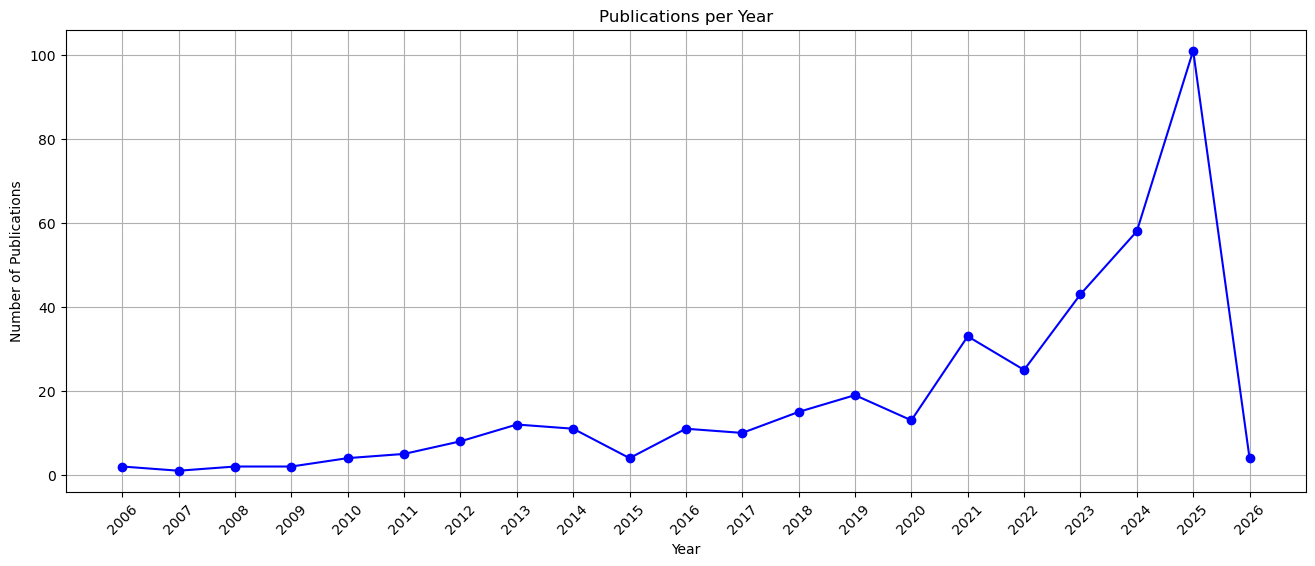

In [31]:

# Ensure 'Year' is numeric
all_data["Year"] = pd.to_numeric(all_data["Year"], errors="coerce")

# Convert to integer
all_data["Year"] = all_data["Year"].astype(int)

# Group by year and count
year_counts = all_data.groupby("Year").size()

# Plot
plt.figure(figsize=(16,6))
plt.plot(year_counts.index, year_counts.values, marker='o', linestyle='-', color='blue')
plt.xticks(year_counts.index, rotation=45)  # integer years on x-axis
plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Publications per Year")
plt.grid(True)

plt.savefig("data/img/publications_per_year.png", bbox_inches = "tight")

plt.show()

In [32]:
import re
import numpy as np

# Step 1: normalize all cells to proper lists, splitting on ',' or ';'
def normalize_keywords(k):
    if k is None:
        return []
    if isinstance(k, (list, np.ndarray)):
        result = []
        for item in k:
            if item is None:
                continue
            # Split on comma or semicolon using regex
            result.extend([x.strip() for x in re.split(r"[;,]", str(item)) if x.strip()])
        return result
    if isinstance(k, str):
        return [x.strip() for x in re.split(r"[;,]", k) if x.strip()]
    return [str(k).strip()]

all_data["Keywords"] = all_data["Keywords"].apply(normalize_keywords)

# Step 2: explode
keywords_exploded = all_data.explode("Keywords")

# Step 3: clean and count
keywords_exploded["Keywords"] = keywords_exploded["Keywords"].str.lower()
keyword_counts = keywords_exploded["Keywords"].value_counts()

keyword_counts.head(60)

Keywords
fall detection                   339
privacy                           83
feature extraction                80
older adults                      71
deep learning                     69
accuracy                          65
monitoring                        62
sensors                           56
real-time systems                 52
radar detection                   48
senior citizens                   44
cameras                           44
radar                             43
machine learning                  40
training                          39
medical services                  35
safety                            31
internet of things                30
accelerometers                    30
human activity recognition        28
security                          24
biomedical monitoring             24
wearable devices                  24
wearable sensors                  24
wireless fidelity                 23
pose estimation                   22
sensor systems               